In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file
import pandas as pd
data = pd.read_csv(r"C:\Users\Disha\IISER - B Summer Internship\US Wheat Futures Historical Data.csv")

In [3]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


In [4]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [5]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)
data = data.drop('Date', axis=1)

# Show the updated dataset
print(data.head())

    Price    Open    High     Low      Vol.
0  792.00  781.25  799.00  765.50   97480.0
1  776.00  755.00  778.00  738.75  165670.0
2  753.50  742.50  772.00  737.60   32610.0
3  734.25  763.25  768.00  723.50  189690.0
4  761.00  793.25  799.25  755.75  213750.0


In [6]:
# Feature engineering to join 3 attributes
data['OpenHighLow'] = data['Open'] * data['High']  * data['Low']

In [7]:
# extract features and target
X = data[['Open', 'High', 'Low','Vol.']]
y = data['Price']

In [8]:
from sklearn.model_selection import train_test_split

# Split the data into a 98/2 train/test split
train_X, test_X, train_y, test_y = train_test_split(data, y, test_size=0.02,random_state=42)

In [9]:
# Standardising the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train = scaler.fit_transform(train_X)
test = scaler.transform(test_X)

In [10]:
# perform feature selection
from sklearn.feature_selection import SelectKBest, f_regression
selector = SelectKBest(f_regression, k=3)
X_train_selected = selector.fit_transform(train_X, train_y)
X_test_selected = selector.transform(test_X)

In [11]:
from sklearn.svm import SVR

# Define the SVM regressor
svr_model = SVR(kernel='rbf')

# Define the hyperparameters to tune
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

In [12]:
# Importing library for Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Perform a grid search to find the optimal hyperparameters 
grid_search = GridSearchCV(svr_model, param_grid, cv=5)
grid_search.fit(train_X, train_y)

GridSearchCV(cv=5, error_score=nan,
             estimator=SVR(C=1.0, cache_size=200, coef0=0.0, degree=3,
                           epsilon=0.1, gamma='scale', kernel='rbf',
                           max_iter=-1, shrinking=True, tol=0.001,
                           verbose=False),
             iid='deprecated', n_jobs=None,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 1, 10]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [13]:
# Get the best hyperparameters and fit the model on training data
best_params = grid_search.best_params_
svr_model = SVR(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'])
svr_model.fit(train_X, train_y)

SVR(C=100, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='scale',
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [14]:
# Make predictions on test data
pred = svr_model.predict(test_X)

In [15]:
from sklearn.metrics import r2_score

# Calculate R-squared
r2 = r2_score(test_y, pred)
print(r2)

0.989955216943072


In [16]:
from sklearn.metrics import mean_squared_error

# Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(test_y, pred))
print("Root Mean Squared Error: ", rmse)

Root Mean Squared Error:  15.961135593567732


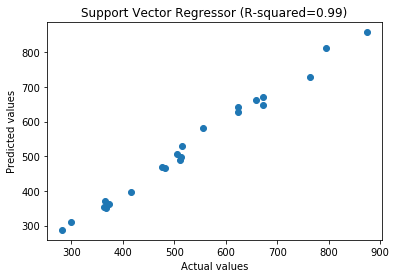

In [17]:
# Plot actual vs predicted values
plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Support Vector Regressor (R-squared={r2:.2f})")
plt.show()